# FSNM on the Conditional Density Estimation benchmark

This notebook evaluates FSNM, without changing its implementation, on the synthetic simulators from [`freelunchtheorem/Conditional_Density_Estimation`](https://github.com/freelunchtheorem/Conditional_Density_Estimation). It is an exploratory FSNM-only run before comparison with Neural Conditional Probability (NCP).

The primary distributional metric is the conditional-CDF Kolmogorov--Smirnov (KS) error. We report both the raw low-rank operator estimate and a transparent CDF repair obtained by clipping to $[0,1]$ and taking the cumulative maximum over the response grid. Hyperparameters are fixed across datasets and are not selected using the true CDF.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# The expected layout is external/fsnm next to external/Conditional_Density_Estimation.
FSNM_ROOT = Path.cwd().resolve()
if not (FSNM_ROOT / "src" / "fsnm.py").exists():
    FSNM_ROOT = Path.cwd().resolve().parent
CDE_ROOT = FSNM_ROOT.parent / "Conditional_Density_Estimation"
if not CDE_ROOT.exists():
    raise FileNotFoundError("Clone freelunchtheorem/Conditional_Density_Estimation next to the FSNM repository.")

sys.path.insert(0, str(FSNM_ROOT / "src"))
sys.path.insert(0, str(CDE_ROOT))

from fsnm import empirical_loss, fit_fsnm
from cde.density_simulation import (
    ArmaJump,
    EconDensity,
    GaussianMixture,
    LinearGaussian,
    SkewNormal,
)

print(f"FSNM repository: {FSNM_ROOT}")
print(f"CDE benchmark:   {CDE_ROOT}")

FSNM repository: /Users/alekfrohlich/latex-fsnm/external/fsnm
CDE benchmark:   /Users/alekfrohlich/latex-fsnm/external/Conditional_Density_Estimation


## Configuration

`QUICK_RUN=True` executes one seed with moderate sample size. Set it to `False` for the intended paper-scale protocol of 10 repetitions and $n=10^4$ training pairs. Both modes use independent training, validation, and test samples.

In [2]:
QUICK_RUN = True

if QUICK_RUN:
    SEEDS = [0]
    N_TRAIN, N_VALIDATION, N_TEST = 3_000, 1_000, 3_000
    RANK, N_ITERATIONS = 10, 15
    N_CONDITIONING, N_Y_GRID = 31, 301
else:
    SEEDS = list(range(10))
    N_TRAIN, N_VALIDATION, N_TEST = 10_000, 2_000, 10_000
    RANK, N_ITERATIONS = 50, 50
    N_CONDITIONING, N_Y_GRID = 101, 501

FSNM_KWARGS = dict(
    rank=RANK,
    n_iterations=N_ITERATIONS,
    step_size=0.1,
    max_depth=4,
    min_samples_leaf=max(30, N_TRAIN // 50),
    patience=8 if QUICK_RUN else 15,
)

DATASETS = [
    "LinearGaussian",
    "EconDensity",
    "ArmaJump",
    "GaussianMixture",
    "SkewNormal",
]

FSNM_KWARGS

{'rank': 10,
 'n_iterations': 15,
 'step_size': 0.1,
 'max_depth': 4,
 'min_samples_leaf': 60,
 'patience': 8}

## Benchmark and evaluation helpers

The LinearGaussian parameters follow the version used in the NCP CDE benchmark, $Y=X+\mathcal N(0,0.1^2)$. The other simulators use the CDE package defaults. ArmaJump produces a stationary transition-pair sample after burn-in; all other simulators produce i.i.d. pairs.

In [3]:
def make_simulator(name, seed):
    if name == "LinearGaussian":
        return LinearGaussian(mu=0.0, mu_slope=1.0, std=0.1, std_slope=0.0, random_seed=seed)
    if name == "EconDensity":
        return EconDensity(std=1.0, heteroscedastic=True, random_seed=seed)
    if name == "ArmaJump":
        return ArmaJump(random_seed=seed)
    if name == "GaussianMixture":
        return GaussianMixture(n_kernels=5, ndim_x=1, ndim_y=1, random_seed=seed)
    if name == "SkewNormal":
        return SkewNormal(random_seed=seed)
    raise ValueError(f"Unknown simulator: {name}")


def simulate_split(name, seed, n_samples):
    simulator = make_simulator(name, seed)
    x, y = simulator.simulate(n_samples=n_samples)
    return simulator, np.asarray(x).reshape(n_samples, -1), np.asarray(y).reshape(n_samples, -1)


def fsnm_conditional_cdf(phi_model, psi_model, singular_values, y_reference, x, y_grid):
    """Evaluate E[1{Y <= y} | X=x] using the learned finite-rank operator."""
    y_reference = np.asarray(y_reference).reshape(-1)
    y_grid = np.asarray(y_grid).reshape(-1)
    psi_reference = psi_model.predict(y_reference[:, None])

    order = np.argsort(y_reference)
    sorted_y = y_reference[order]
    cumulative_psi = np.vstack([np.zeros((1, psi_reference.shape[1])), np.cumsum(psi_reference[order], axis=0)])
    indices = np.searchsorted(sorted_y, y_grid, side="right")
    marginal_cdf = indices / len(sorted_y)
    spectral_moments = cumulative_psi[indices] / len(sorted_y)

    weighted_phi = phi_model.predict(x) * np.asarray(singular_values)
    raw_cdf = marginal_cdf[None, :] + weighted_phi @ spectral_moments.T
    repaired_cdf = np.maximum.accumulate(np.clip(raw_cdf, 0.0, 1.0), axis=1)
    return raw_cdf, repaired_cdf


def true_conditional_cdf(simulator, x, y_grid):
    n_x, n_y = len(x), len(y_grid)
    repeated_x = np.repeat(x, n_y, axis=0)
    tiled_y = np.tile(y_grid, n_x)
    # SkewNormal.cdf assigns one-element arrays to scalars, which fails on
    # recent NumPy versions. Evaluate its documented distribution directly.
    if isinstance(simulator, SkewNormal):
        loc, scale, skew = simulator._loc_scale_skew_mapping(repeated_x)
        values = stats.skewnorm.cdf(
            tiled_y, skew.ravel(), loc=loc.ravel(), scale=scale.ravel()
        )
        return values.reshape(n_x, n_y)
    return np.asarray(simulator.cdf(repeated_x, tiled_y)).reshape(n_x, n_y)


def conditioning_grid(x, n_points):
    if x.shape[1] != 1:
        raise ValueError("This CDF benchmark currently expects one-dimensional X.")
    probabilities = np.linspace(0.02, 0.98, n_points)
    return np.quantile(x[:, 0], probabilities)[:, None]


def response_grid(y, n_points):
    lower, upper = np.quantile(y[:, 0], [0.001, 0.999])
    margin = 0.05 * (upper - lower)
    return np.linspace(lower - margin, upper + margin, n_points)


## Run FSNM

The true conditional CDF is used only for evaluation. Early stopping uses the held-out FSNM objective.

In [4]:
records = []
curves = {}

for dataset in DATASETS:
    for seed in SEEDS:
        print(f"Fitting {dataset}, seed={seed} ...", flush=True)
        _, x_train, y_train = simulate_split(dataset, 10_000 + seed, N_TRAIN)
        _, x_validation, y_validation = simulate_split(dataset, 20_000 + seed, N_VALIDATION)
        test_simulator, x_test, y_test = simulate_split(dataset, 30_000 + seed, N_TEST)

        start = time.perf_counter()
        phi_model, psi_model, singular_values, history = fit_fsnm(
            x_train,
            y_train,
            seed=seed,
            validation_data=(x_validation, y_validation),
            **FSNM_KWARGS,
        )
        fit_seconds = time.perf_counter() - start

        x_grid = conditioning_grid(x_test, N_CONDITIONING)
        y_grid = response_grid(y_test, N_Y_GRID)
        raw_cdf, repaired_cdf = fsnm_conditional_cdf(phi_model, psi_model, singular_values, y_train, x_grid, y_grid)
        target_cdf = true_conditional_cdf(test_simulator, x_grid, y_grid)

        raw_ks_by_x = np.max(np.abs(raw_cdf - target_cdf), axis=1)
        repaired_ks_by_x = np.max(np.abs(repaired_cdf - target_cdf), axis=1)
        test_loss = empirical_loss(phi_model.predict(x_test), psi_model.predict(y_test))
        range_violation = np.mean((raw_cdf < 0.0) | (raw_cdf > 1.0))
        monotonicity_violation = np.mean(np.diff(raw_cdf, axis=1) < -1e-10)

        records.append(
            dict(
                dataset=dataset,
                seed=seed,
                test_loss=test_loss,
                mean_ks_raw=raw_ks_by_x.mean(),
                mean_ks_repaired=repaired_ks_by_x.mean(),
                median_ks_repaired=np.median(repaired_ks_by_x),
                max_ks_repaired=repaired_ks_by_x.max(),
                raw_range_violation=range_violation,
                raw_monotonicity_violation=monotonicity_violation,
                fit_seconds=fit_seconds,
                best_iteration=history["best_iteration"],
            )
        )
        if seed == SEEDS[0]:
            curves[dataset] = dict(x=x_grid, y=y_grid, target=target_cdf, raw=raw_cdf, repaired=repaired_cdf)

columns = [
    "dataset",
    "seed",
    "test_loss",
    "mean_ks_raw",
    "mean_ks_repaired",
    "max_ks_repaired",
    "raw_range_violation",
    "raw_monotonicity_violation",
    "fit_seconds",
    "best_iteration",
]
print(" | ".join(columns))
for record in records:
    print(
        " | ".join(
            str(record[column]) if isinstance(record[column], (str, int, np.integer)) else f"{record[column]:.5g}"
            for column in columns
        )
    )

Fitting LinearGaussian, seed=0 ...


Fitting EconDensity, seed=0 ...


Fitting ArmaJump, seed=0 ...


Fitting GaussianMixture, seed=0 ...


Fitting SkewNormal, seed=0 ...


dataset | seed | test_loss | mean_ks_raw | mean_ks_repaired | max_ks_repaired | raw_range_violation | raw_monotonicity_violation | fit_seconds | best_iteration
LinearGaussian | 0 | 10.575 | 0.082829 | 0.082829 | 0.099191 | 0.037831 | 0 | 0.57085 | 1
EconDensity | 0 | 8.6062 | 0.083798 | 0.083798 | 0.25752 | 0.17008 | 0.063978 | 1.3353 | 9
ArmaJump | 0 | 1.3116 | 0.24257 | 0.24257 | 0.39419 | 0.12689 | 0.056129 | 0.94447 | 5
GaussianMixture | 0 | 9.2794 | 0.094559 | 0.094559 | 0.23355 | 0.080056 | 0 | 0.86217 | 4
SkewNormal | 0 | 5.8602 | 0.07401 | 0.07368 | 0.20762 | 0.31486 | 0.13366 | 1.2291 | 11


## Aggregate results

In [5]:
summary = {}
for dataset in DATASETS:
    rows = [record for record in records if record["dataset"] == dataset]
    summary[dataset] = dict(
        mean_ks=np.mean([row["mean_ks_repaired"] for row in rows]),
        std_ks=np.std([row["mean_ks_repaired"] for row in rows], ddof=1) if len(rows) > 1 else np.nan,
        mean_raw_ks=np.mean([row["mean_ks_raw"] for row in rows]),
        mean_test_loss=np.mean([row["test_loss"] for row in rows]),
        mean_fit_seconds=np.mean([row["fit_seconds"] for row in rows]),
        mean_best_iteration=np.mean([row["best_iteration"] for row in rows]),
    )

print("dataset | mean KS | std KS | raw KS | test loss | seconds | best iteration")
for dataset, values in summary.items():
    print(
        f"{dataset} | {values['mean_ks']:.5g} | {values['std_ks']:.5g} | "
        f"{values['mean_raw_ks']:.5g} | {values['mean_test_loss']:.5g} | "
        f"{values['mean_fit_seconds']:.3g} | {values['mean_best_iteration']:.3g}"
    )

dataset | mean KS | std KS | raw KS | test loss | seconds | best iteration
LinearGaussian | 0.082829 | nan | 0.082829 | 10.575 | 0.571 | 1
EconDensity | 0.083798 | nan | 0.083798 | 8.6062 | 1.34 | 9
ArmaJump | 0.24257 | nan | 0.24257 | 1.3116 | 0.944 | 5
GaussianMixture | 0.094559 | nan | 0.094559 | 9.2794 | 0.862 | 4
SkewNormal | 0.07368 | nan | 0.07401 | 5.8602 | 1.23 | 11


## Conditional-CDF diagnostics

For each simulator, the panels show three conditioning quantiles. Dashed curves are the analytic CDFs and solid curves are the repaired FSNM estimates.

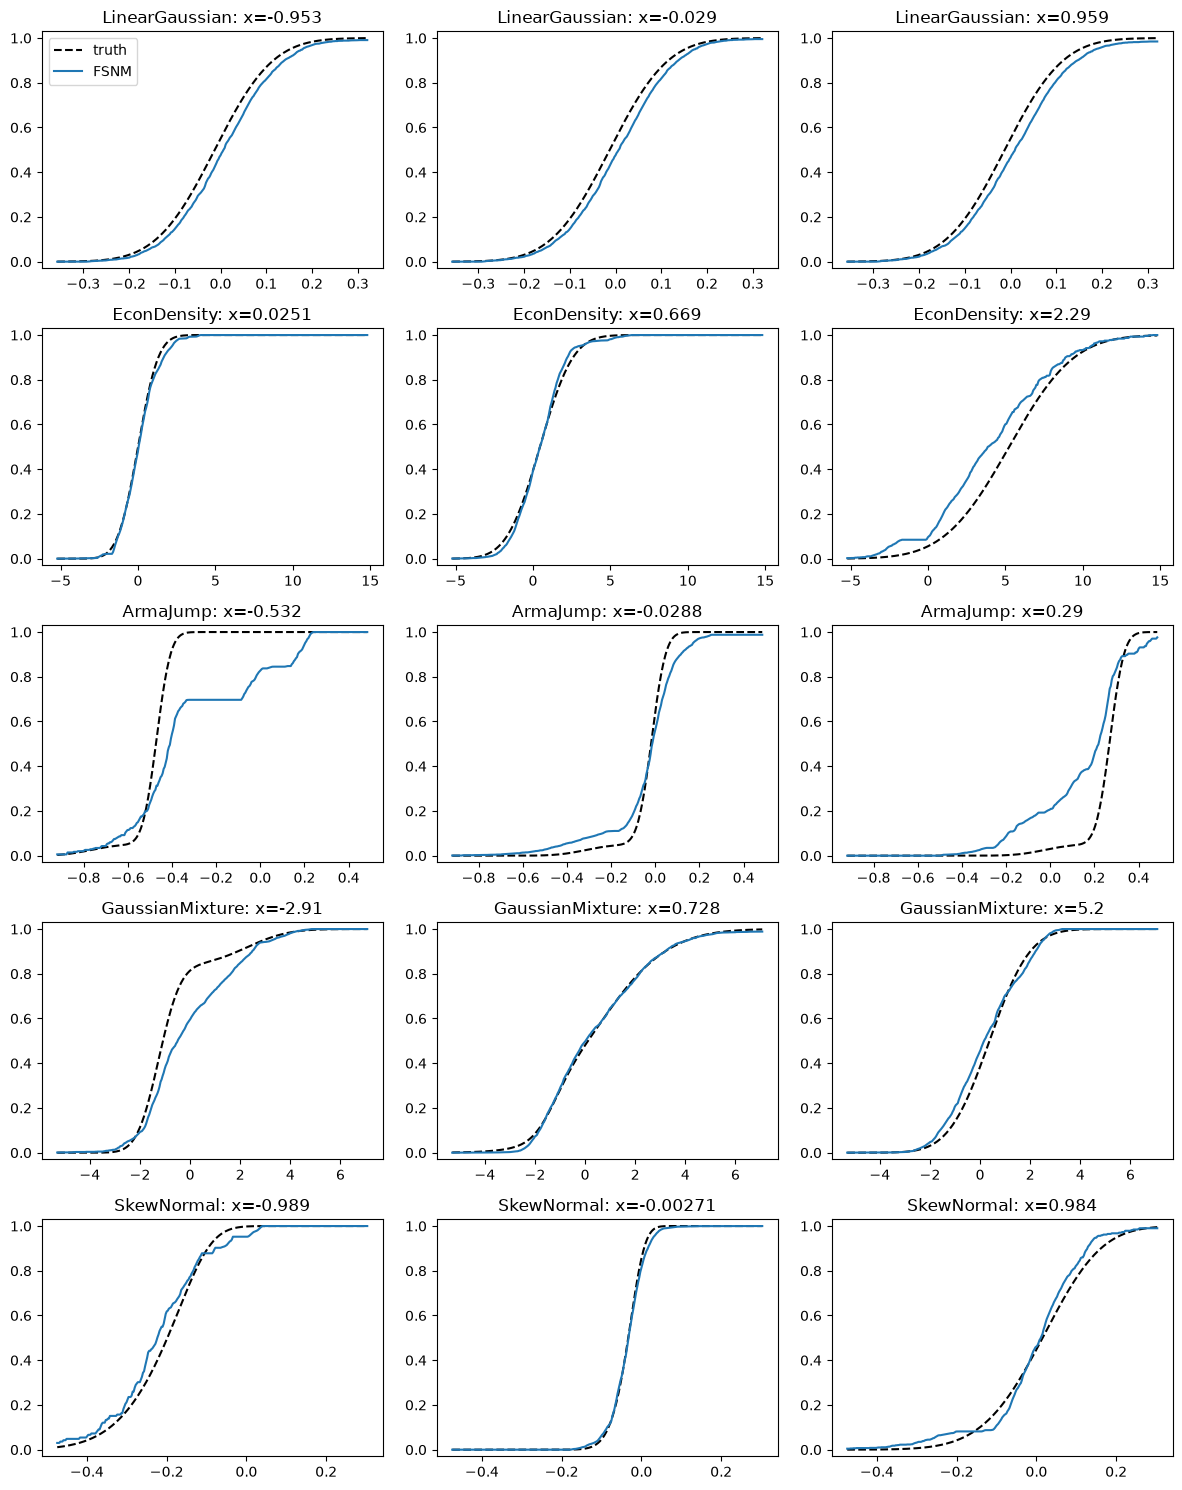

In [6]:
figure, axes = plt.subplots(len(DATASETS), 3, figsize=(12, 3 * len(DATASETS)), squeeze=False)
selected = [0, N_CONDITIONING // 2, N_CONDITIONING - 1]

for row, dataset in enumerate(DATASETS):
    data = curves[dataset]
    for column, index in enumerate(selected):
        axis = axes[row, column]
        axis.plot(data["y"], data["target"][index], "k--", label="truth")
        axis.plot(data["y"], data["repaired"][index], color="tab:blue", label="FSNM")
        axis.set_title(f"{dataset}: x={data['x'][index, 0]:.3g}")
        axis.set_ylim(-0.03, 1.03)
        if row == 0 and column == 0:
            axis.legend()

figure.tight_layout()
plt.show()

## Interpretation

This notebook is deliberately FSNM-only. Its purpose is to validate that the current implementation can be evaluated on the established CDE simulators and to expose failure modes before adding NCP. The full comparison should use identical generated splits, rank selection by validation loss, and the same KS evaluation code for both methods.